<a href="https://colab.research.google.com/github/ekarau/Deep-Learning-with-Python-Project/blob/main/Aktivasyon_Fonksiyonlar%C4%B1n%C4%B1n__E%C4%9FitimSetine_Etkisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


Adam: 100%|██████████| 10/10 [01:47<00:00, 10.72s/it]


| Model          |   Final Acc |   Best Acc |   Dead % |
|:---------------|------------:|-----------:|---------:|
| ReLU           |       91.51 |      91.51 |     4.1  |
| Sigmoid        |       11.35 |      11.35 |     0    |
| Tanh           |       91.5  |      91.5  |     0    |
| LeakyReLU      |       91.68 |      91.68 |     0    |
| ReLU_NoDropout |       91.51 |      91.51 |     7.23 |
| ReLU_L2        |       91.45 |      91.45 |     3.71 |
| SGD            |       91.18 |      91.18 |     4.3  |
| Momentum       |       97.61 |      97.63 |     2.15 |
| Adam           |       95.66 |      95.66 |    45.7  |


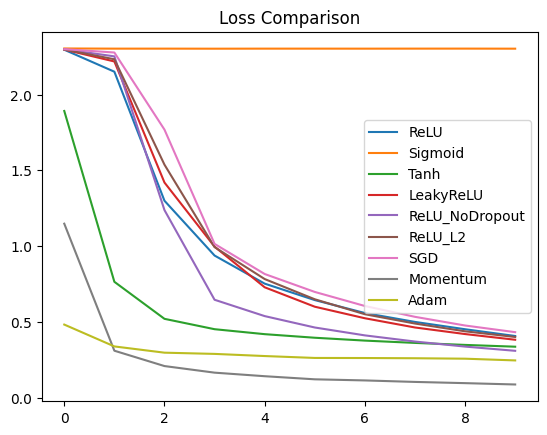

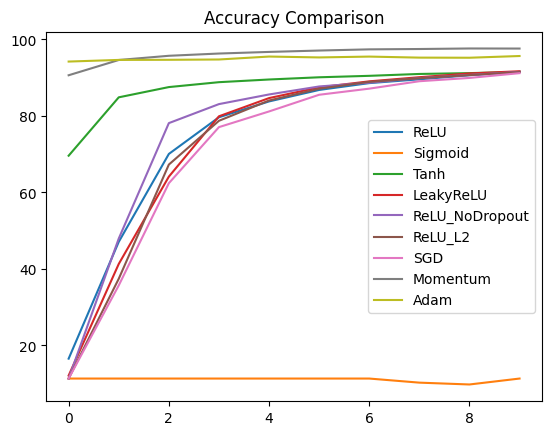

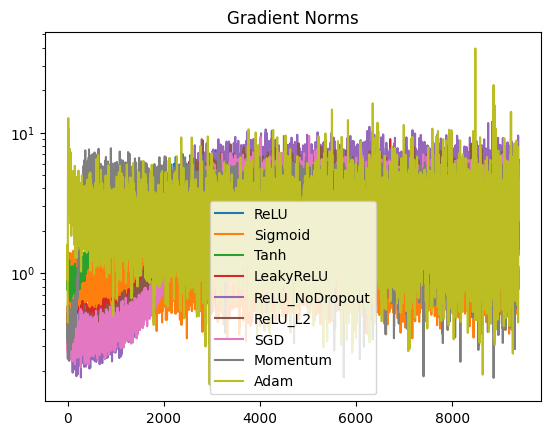

In [4]:
# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETUP
# =========================
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# DATA
# =========================
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

# =========================
# MODEL
# =========================
class DeepMLP(nn.Module):
    def __init__(self, activation_fn, use_dropout=True):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.ModuleList([
            nn.Linear(28*28, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
        ])

        self.activation = activation_fn
        self.dropout = nn.Dropout(0.2) if use_dropout else nn.Identity()
        self.out = nn.Linear(128, 10)

    def forward(self, x, store_activations=False):
        x = self.flatten(x)
        self._acts = []

        for i, layer in enumerate(self.layers):
            x = self.activation(layer(x))
            if store_activations:
                self._acts.append(x.detach().cpu())
            if i < 3:
                x = self.dropout(x)

        return self.out(x)

# =========================
# DEAD NEURON ANALYSIS
# =========================
def compute_dead_neurons(model, loader, n_batches=3):
    model.eval()
    sums = None

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batches:
                break
            x = x.to(device)
            _ = model(x, store_activations=True)
            acts = model._acts

            if sums is None:
                sums = [torch.zeros(a.shape[1]) for a in acts]

            for j, a in enumerate(acts):
                sums[j] += a.abs().sum(dim=0)

    dead = [(s == 0).sum().item() for s in sums]
    total = sum(s.numel() for s in sums)
    return sum(dead)/total * 100

# =========================
# TRAIN FUNCTION
# =========================
def train_model(name, activation, optimizer_type="sgd", lr=0.01, weight_decay=0.0, use_dropout=True):

    model = DeepMLP(activation, use_dropout).to(device)

    # OPTIMIZER
    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_fn = nn.CrossEntropyLoss()

    losses, accs = [], []
    grad_norms = []

    for epoch in tqdm(range(10), desc=name):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()

            # Gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.norm().item()
            grad_norms.append(total_norm)

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss / len(train_loader))

        # TEST
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        accs.append(100 * correct / total)

    dead_pct = compute_dead_neurons(model, train_loader)

    return {
        "loss": losses,
        "acc": accs,
        "grad": grad_norms,
        "dead": dead_pct
    }

# =========================
# EXPERIMENTS
# =========================
results = {}

def run(name, **kwargs):
    results[name] = train_model(name, **kwargs)

# ACTIVATION
run("ReLU", activation=nn.ReLU())
run("Sigmoid", activation=nn.Sigmoid())
run("Tanh", activation=nn.Tanh())
run("LeakyReLU", activation=nn.LeakyReLU(0.01))

# REGULARIZATION
run("ReLU_NoDropout", activation=nn.ReLU(), use_dropout=False)
run("ReLU_L2", activation=nn.ReLU(), weight_decay=1e-4)

# OPTIMIZER
run("SGD", activation=nn.ReLU(), optimizer_type="sgd")
run("Momentum", activation=nn.ReLU(), optimizer_type="momentum")
run("Adam", activation=nn.ReLU(), optimizer_type="adam")

# =========================
# TABLE
# =========================
rows = []
for name, r in results.items():
    rows.append({
        "Model": name,
        "Final Acc": round(r["acc"][-1],2),
        "Best Acc": round(max(r["acc"]),2),
        "Dead %": round(r["dead"],2)
    })

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

# =========================
# GRAPHS
# =========================

# LOSS
plt.figure()
for name, r in results.items():
    plt.plot(r["loss"], label=name)
plt.title("Loss Comparison")
plt.legend()

# ACCURACY
plt.figure()
for name, r in results.items():
    plt.plot(r["acc"], label=name)
plt.title("Accuracy Comparison")
plt.legend()

# GRADIENT
plt.figure()
for name, r in results.items():
    plt.plot(r["grad"], label=name)
plt.title("Gradient Norms")
plt.yscale("log")
plt.legend()

plt.show()